# Weight Norm Dynamics + Training Curves

Tracks parameter RMS norm throughout training for 6 key configurations.
Weight norm is computed **inside the CUDA graph** — zero CPU overhead.

**Est. T4 runtime: ~8 min** (6 configs × ~1.3 min each)

> Runtime → Change runtime type → T4 GPU

In [1]:
import torch, time, random, numpy as np, pandas as pd
import torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt, warnings
from itertools import product as iproduct
from copy import deepcopy
from torch.amp import autocast

assert torch.cuda.is_available(), "Need T4 GPU!"
print("GPU:", torch.cuda.get_device_name(0))
torch.backends.cudnn.benchmark        = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32       = True
print("PyTorch:", torch.__version__)

P=97; TRAIN_FRACTION=0.2; CLIP=1.0; DEVICE="cuda"
LOG_EVERY = 2_000

def make_data(seed=0, op="add"):
    random.seed(seed)
    if op == "add":
        pairs = list(iproduct(range(P), range(P)))
        targets = lambda x: (x[:,0]+x[:,1])%P
    else:  # mul — exclude a=0 or b=0
        pairs = [(a,b) for a in range(1,P) for b in range(1,P)]
        targets = lambda x: (x[:,0]*x[:,1])%P
    random.shuffle(pairs)
    n = int(len(pairs)*TRAIN_FRACTION)
    def tt(d):
        x = torch.tensor(d, dtype=torch.long, device=DEVICE)
        return x, targets(x)
    return tt(pairs[:n]), tt(pairs[n:])

def accuracy(logits, y): return (logits.argmax(-1)==y).float().mean().item()

class MLP(nn.Module):
    def __init__(self, width=512, depth=4, act=nn.GELU):
        super().__init__()
        self.embed = nn.Embedding(P, width)
        layers = []
        for _ in range(depth): layers += [nn.Linear(width,width), act()]
        self.mlp = nn.Sequential(*layers)
        self.out = nn.Linear(width, P)
    def forward(self, x):
        return self.out(self.mlp(self.embed(x[:,0])+self.embed(x[:,1])))

class Transformer(nn.Module):
    def __init__(self, width=512, heads=4):
        super().__init__()
        self.embed     = nn.Embedding(P, width)
        self.pos_embed = nn.Parameter(torch.randn(2,width)*0.02)
        enc = nn.TransformerEncoderLayer(d_model=width, nhead=heads,
            dim_feedforward=width*4, activation="gelu", dropout=0.0,
            batch_first=True, norm_first=True)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", UserWarning)
            self.transformer = nn.TransformerEncoder(enc, num_layers=1)
        self.out = nn.Linear(width, P)
    def forward(self, x):
        h = self.embed(x)+self.pos_embed
        return self.out(self.transformer(h).mean(1))

# ── CUDA-graph training with in-graph weight norm ──────────────────────────
def cuda_graph_train(model, optimizer, tx, ty, vx, vy,
                     steps=400_000, log_every=LOG_EVERY):
    """
    Full CUDA graph training loop.
    Weight norm is computed INSIDE the graph into a static buffer —
    zero CPU syncs during training steps.
    """
    model.train()

    # Static buffer for weight norm — written by graph, read at eval
    wn_buf = torch.zeros(1, device=DEVICE)

    # Warmup: 11 normal steps to trigger torch.compile
    for _ in range(11):
        optimizer.zero_grad(set_to_none=True)
        F.cross_entropy(model(tx), ty).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP)
        optimizer.step()
    torch.cuda.synchronize()

    # Capture graph: forward + backward + clip + step + weight norm
    g = torch.cuda.CUDAGraph()
    optimizer.zero_grad(set_to_none=True)
    with torch.cuda.graph(g):
        loss_g = F.cross_entropy(model(tx), ty)
        loss_g.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP)
        optimizer.step()
        # Compute RMS weight norm inside graph — no CPU sync needed
        sq_sum = torch.zeros(1, device=DEVICE)
        n_params = 0
        for p in model.parameters():
            sq_sum += p.detach().pow(2).sum()
            n_params += p.numel()
        wn_buf.copy_(torch.sqrt(sq_sum / n_params))
    torch.cuda.synchronize()

    T_train = T_test = None
    history = []   # {step, train_acc, test_acc, weight_norm}
    t0 = time.time()

    for step in range(steps):
        g.replay()   # entire step: fwd+bwd+opt+wn — no Python overhead

        if step % log_every == 0:
            torch.cuda.synchronize()   # sync once per LOG_EVERY
            model.eval()
            with torch.no_grad(), autocast("cuda"):
                tr = accuracy(model(tx), ty)
                te = accuracy(model(vx), vy)
            model.train()
            wn = wn_buf.item()   # single scalar read, already on CPU buffer
            history.append({"step":step,"train":tr,"test":te,"weight_norm":wn})

            if T_train is None and tr >= 0.99: T_train = step
            if T_test  is None and te >= 0.99:
                T_test = step
                print(f"    GROKKED step={step} T_train={T_train} "
                      f"delay={T_test-T_train} wn={wn:.4f} "
                      f"t={(time.time()-t0)/60:.1f}m")
                break
            if step % (log_every*10) == 0:
                print(f"    step={step:>7} tr={tr:.3f} te={te:.3f} "
                      f"wn={wn:.3f} t={(time.time()-t0)/60:.1f}m")

    return T_train, T_test, history


def run_config(name, model_factory, opt_factory, seed=0, steps=400_000, op="add"):
    """Run a single configuration and return results."""
    print(f"  {name} seed={seed}")
    torch.manual_seed(seed)
    (tx,ty),(vx,vy) = make_data(seed, op=op)
    model = torch.compile(model_factory().to(DEVICE))
    opt   = opt_factory(model)
    T_train, T_test, history = cuda_graph_train(model, opt, tx, ty, vx, vy, steps)
    delay = (T_test-T_train) if (T_train and T_test) else None
    return {"name":name,"seed":seed,"T_train":T_train,"T_test":T_test,
            "delay":delay,"history":history,"model":model}

print("Setup complete. CUDA graph training ready.")


GPU: Tesla T4
PyTorch: 2.10.0+cu128
Setup complete. CUDA graph training ready.


In [4]:
CONFIGS = [
    ("""Depth-2 GELU
(baseline)""",
     lambda: MLP(width=256, depth=2),
     lambda m: torch.optim.SGD(m.parameters(), lr=1e-2, weight_decay=2e-3, momentum=0.9),
     0, 400_000),
    ("""MLP GELU
(H2 config)""",
     lambda: MLP(width=512, depth=4),
     lambda m: torch.optim.SGD(m.parameters(), lr=3e-2, weight_decay=5e-4, momentum=0.9),
     0, 400_000),
    ("""MLP GELU
(optimal lam)""",
     lambda: MLP(width=512, depth=4),
     lambda m: torch.optim.SGD(m.parameters(), lr=3e-2, weight_decay=1e-3, momentum=0.9),
     0, 400_000),
    ("""Transformer
(H2 lam=1.0)""",
     lambda: Transformer(),
     lambda m: torch.optim.AdamW(m.parameters(), lr=1e-3, weight_decay=1.0, capturable=True),
     0, 400_000),
    ("""Transformer
(optimal lam=5.0)""",
     lambda: Transformer(),
     lambda m: torch.optim.AdamW(m.parameters(), lr=1e-3, weight_decay=5.0, capturable=True),
     0, 400_000),
    ("""MLP ReLU
(Sweep-B)""",
     lambda: MLP(width=512, depth=4, act=nn.ReLU),
     lambda m: torch.optim.SGD(m.parameters(), lr=3e-2, weight_decay=5e-4, momentum=0.9),
     0, 400_000),
]

all_results = []
for name, mf, of, seed, steps in CONFIGS:
    print(f"\n=== {name.replace(chr(10),' ')} ===")
    t0 = time.time()
    r = run_config(name, mf, of, seed=seed, steps=steps)
    print(f"  done in {(time.time()-t0)/60:.1f}m  delay={r['delay']}")
    all_results.append(r)

print("\nAll configs done!")
print("Summary:")
for r in all_results:
    print(f"  {r['name'].replace(chr(10),' '):<30} delay={r['delay']}")


=== Depth-2 GELU (baseline) ===
  Depth-2 GELU
(baseline) seed=0
    step=      0 tr=0.013 te=0.010 wn=0.372 t=0.0m
    step=  20000 tr=1.000 te=0.745 wn=0.081 t=0.3m
    GROKKED step=34000 T_train=2000 delay=32000 wn=0.0695 t=0.5m
  done in 0.5m  delay=32000

=== MLP GELU (H2 config) ===
  MLP GELU
(H2 config) seed=0
    step=      0 tr=0.019 te=0.010 wn=0.209 t=0.0m
    step=  20000 tr=1.000 te=0.205 wn=0.032 t=1.5m
    step=  40000 tr=1.000 te=0.279 wn=0.028 t=3.0m
    GROKKED step=56000 T_train=2000 delay=54000 wn=0.0236 t=4.1m
  done in 4.1m  delay=54000

=== MLP GELU (optimal lam) ===
  MLP GELU
(optimal lam) seed=0
    step=      0 tr=0.020 te=0.010 wn=0.209 t=0.0m
    step=  20000 tr=1.000 te=0.273 wn=0.028 t=1.5m
    GROKKED step=28000 T_train=2000 delay=26000 wn=0.0225 t=2.1m
  done in 2.1m  delay=26000

=== Transformer (H2 lam=1.0) ===
  Transformer
(H2 lam=1.0) seed=0
    step=      0 tr=0.560 te=0.089 wn=0.126 t=0.1m
    step=  20000 tr=1.000 te=0.193 wn=0.028 t=11.7m
   


Weight norm at grokking: mean=0.0298 std=0.0180 cv=0.602
Config-by-config:
  Depth-2 GELU         wn=0.0695
  MLP GELU
(H2         wn=0.0236
  MLP GELU
(op         wn=0.0225
  Transformer
         wn=0.0254
  Transformer
         wn=0.0160
  MLP ReLU
(Sw         wn=0.0219


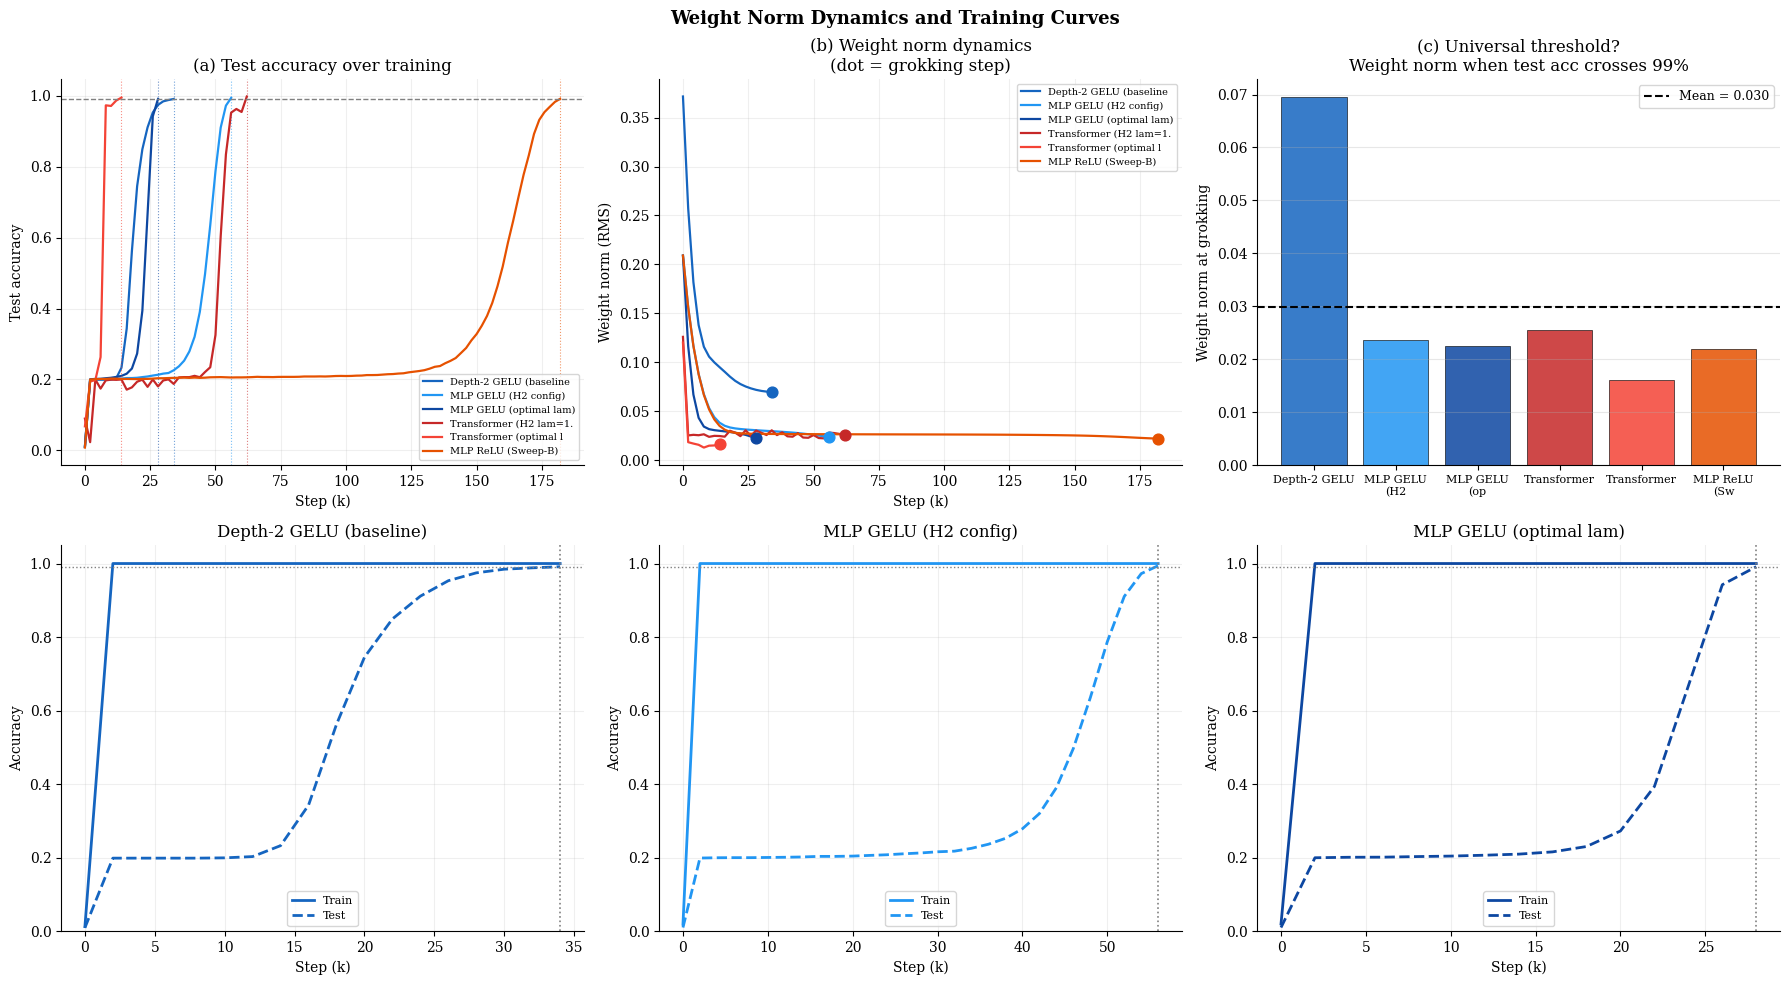

Saved: fig_weight_norm_dynamics.png


In [5]:
plt.rcParams.update({"font.family":"serif","font.size":10,
    "axes.spines.top":False,"axes.spines.right":False})
COLORS = ["#1565C0","#2196F3","#0D47A1","#C62828","#F44336","#E65100"]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ── (a) Test accuracy over training ─────────────────────────────
ax = axes[0,0]
for r, c in zip(all_results, COLORS):
    h = r["history"]
    steps = np.array([e["step"] for e in h])/1000
    test  = [e["test"] for e in h]
    lbl   = r["name"].replace("\n"," ")[:22]
    ax.plot(steps, test, color=c, lw=1.6, label=lbl)
    if r["T_test"]: ax.axvline(r["T_test"]/1000, color=c, lw=0.8, ls=":", alpha=0.6)
ax.axhline(0.99, color="gray", ls="--", lw=1)
ax.set(xlabel="Step (k)", ylabel="Test accuracy", title="(a) Test accuracy over training")
ax.legend(fontsize=7, loc="lower right"); ax.grid(alpha=0.2)

# ── (b) Weight norm over training ───────────────────────────────
ax = axes[0,1]
for r, c in zip(all_results, COLORS):
    h = r["history"]
    steps = np.array([e["step"] for e in h])/1000
    wns   = [e["weight_norm"] for e in h]
    ax.plot(steps, wns, color=c, lw=1.6,
            label=r["name"].replace("\n"," ")[:22])
    if r["T_test"]:
        idx = min(range(len(h)), key=lambda i: abs(h[i]["step"]-r["T_test"]))
        ax.scatter([r["T_test"]/1000],[wns[idx]],color=c,s=60,zorder=5)
ax.set(xlabel="Step (k)", ylabel="Weight norm (RMS)",
       title="(b) Weight norm dynamics\n(dot = grokking step)")
ax.legend(fontsize=7); ax.grid(alpha=0.2)

# ── (c) Weight norm at grokking — universal threshold? ──────────
ax = axes[0,2]
grokked = [r for r in all_results if r["T_test"]]
if grokked:
    labels_wn, wns_at_grok = [], []
    for r in grokked:
        h = r["history"]
        idx = min(range(len(h)), key=lambda i: abs(h[i]["step"]-r["T_test"]))
        wns_at_grok.append(h[idx]["weight_norm"])
        labels_wn.append(r["name"].replace("\n","\n")[:12])
    c_list = [COLORS[all_results.index(r)] for r in grokked]
    ax.bar(range(len(grokked)), wns_at_grok, color=c_list,
           alpha=0.85, edgecolor="black", lw=0.5)
    mean_wn = np.mean(wns_at_grok)
    ax.axhline(mean_wn, color="black", ls="--", lw=1.5,
               label=f"Mean = {mean_wn:.3f}")
    ax.set_xticks(range(len(grokked)))
    ax.set_xticklabels(labels_wn, fontsize=8)
    ax.set(ylabel="Weight norm at grokking",
           title="(c) Universal threshold?\nWeight norm when test acc crosses 99%")
    ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)
    print(f"\nWeight norm at grokking: mean={mean_wn:.4f} "
          f"std={np.std(wns_at_grok):.4f} cv={np.std(wns_at_grok)/mean_wn:.3f}")
    print("Config-by-config:")
    for lbl, wn in zip(labels_wn, wns_at_grok):
        print(f"  {lbl:<20} wn={wn:.4f}")

# ── Row 2: Per-config train+test curves ─────────────────────────
for i, (r, c) in enumerate(zip(all_results[:3], COLORS[:3])):
    ax = axes[1, i]
    h = r["history"]
    steps = np.array([e["step"] for e in h])/1000
    ax.plot(steps, [e["train"] for e in h], color=c, lw=2, label="Train")
    ax.plot(steps, [e["test"]  for e in h], color=c, lw=2, ls="--", label="Test")
    if r["T_test"]: ax.axvline(r["T_test"]/1000, color="gray", ls=":", lw=1.2)
    ax.axhline(0.99, color="gray", ls=":", lw=1)
    ax.set(xlabel="Step (k)", ylabel="Accuracy",
           title=r["name"].replace("\n"," "))
    ax.legend(fontsize=8); ax.grid(alpha=0.2); ax.set_ylim(0, 1.05)

fig.suptitle("Weight Norm Dynamics and Training Curves", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_weight_norm_dynamics.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved: fig_weight_norm_dynamics.png")
